In [1]:
!pip install opencv-python matplotlib

import cv2
import numpy as np


import matplotlib.pyplot as plt
from google.colab import files




Upload one or more aerial images...


Saving mixed iamge 3.jpeg to mixed iamge 3.jpeg
Saving mixed iamge 1.jpeg to mixed iamge 1.jpeg
Saving mixed image.jpeg to mixed image.jpeg

Processing: mixed iamge 3.jpeg
Vegetation: 40.31%
Water: 0.44%
Road: 1.52%
Building: 52.65%


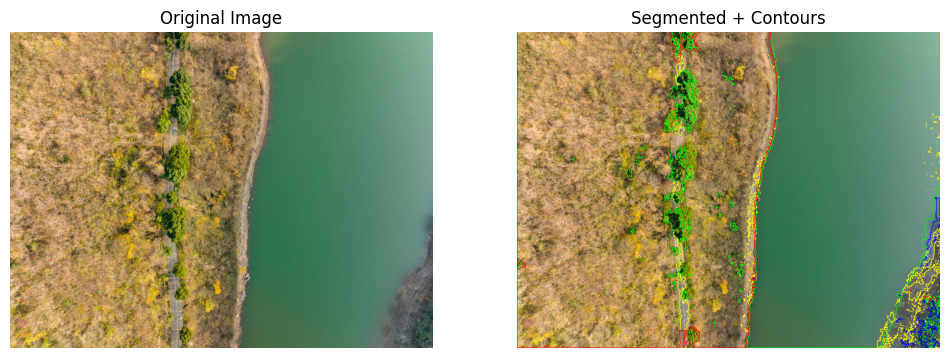


Processing: mixed iamge 1.jpeg
Vegetation: 15.72%
Water: 4.54%
Road: 49.99%
Building: 19.15%


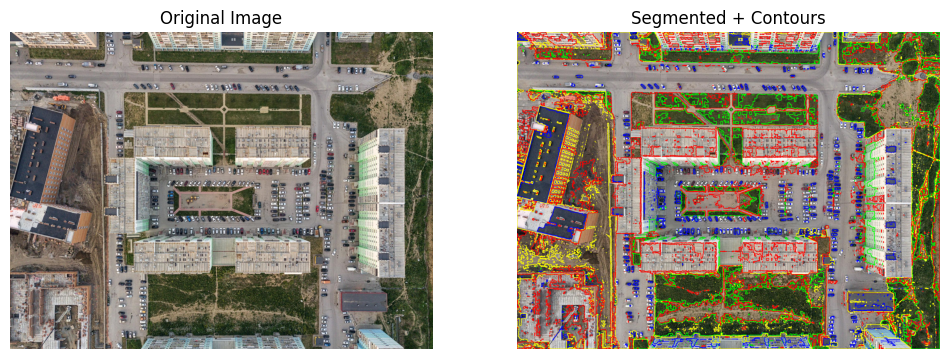


Processing: mixed image.jpeg
Vegetation: 16.78%
Water: 43.79%
Road: 33.49%
Building: 10.33%


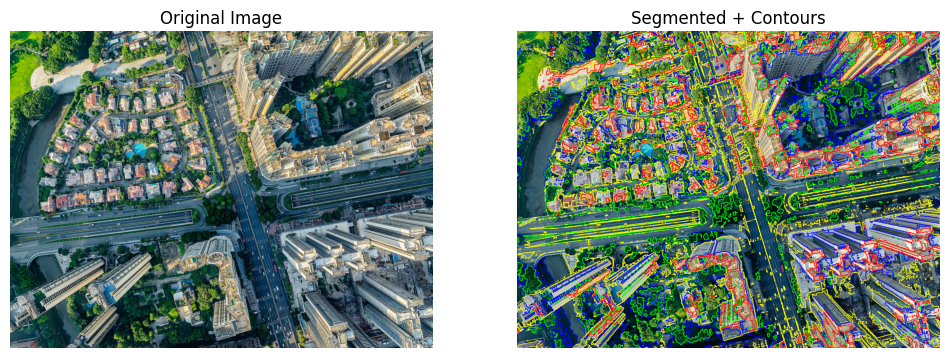

In [3]:
# ================================
# LAND USE CLASSIFICATION PROJECT
# Multi-Image Processing (Colab Ready)
# ================================

!pip install opencv-python matplotlib

import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

print("Upload one or more aerial images...")
uploaded = files.upload()

for image_path in uploaded.keys():

    print("\n==============================")
    print("Processing:", image_path)
    print("==============================")

    # Read Image
    image = cv2.imread(image_path)
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)

    # -----------------------------
    # COLOR SEGMENTATION
    # -----------------------------

    # Vegetation (Green)
    lower_green = np.array([35, 40, 40])
    upper_green = np.array([85, 255, 255])
    mask_green = cv2.inRange(hsv, lower_green, upper_green)

    # Water (Blue)
    lower_blue = np.array([90, 50, 50])
    upper_blue = np.array([130, 255, 255])
    mask_blue = cv2.inRange(hsv, lower_blue, upper_blue)

    # Roads (Gray/White)
    lower_gray = np.array([0, 0, 120])
    upper_gray = np.array([180, 50, 255])
    mask_road = cv2.inRange(hsv, lower_gray, upper_gray)

    # Buildings (Light brown / concrete)
    lower_building = np.array([10, 50, 50])
    upper_building = np.array([25, 255, 255])
    mask_building = cv2.inRange(hsv, lower_building, upper_building)

    # -----------------------------
    # MORPHOLOGICAL CLEANING
    # -----------------------------
    kernel = np.ones((5,5), np.uint8)

    mask_green = cv2.morphologyEx(mask_green, cv2.MORPH_CLOSE, kernel)
    mask_blue = cv2.morphologyEx(mask_blue, cv2.MORPH_CLOSE, kernel)
    mask_road = cv2.morphologyEx(mask_road, cv2.MORPH_CLOSE, kernel)
    mask_building = cv2.morphologyEx(mask_building, cv2.MORPH_CLOSE, kernel)

    # -----------------------------
    # CONTOUR EXTRACTION
    # -----------------------------
    output = image_rgb.copy()

    for mask, color in [(mask_green, (0,255,0)),
                        (mask_blue, (0,0,255)),
                        (mask_road, (255,255,0)),
                        (mask_building, (255,0,0))]:

        contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        for cnt in contours:
            cv2.drawContours(output, [cnt], -1, color, 2)

    # -----------------------------
    # PERCENTAGE CALCULATION
    # -----------------------------
    total_pixels = image.shape[0] * image.shape[1]

    green_percent = (cv2.countNonZero(mask_green) / total_pixels) * 100
    blue_percent = (cv2.countNonZero(mask_blue) / total_pixels) * 100
    road_percent = (cv2.countNonZero(mask_road) / total_pixels) * 100
    building_percent = (cv2.countNonZero(mask_building) / total_pixels) * 100

    # -----------------------------
    # PRINT RESULTS
    # -----------------------------
    print(f"Vegetation: {green_percent:.2f}%")
    print(f"Water: {blue_percent:.2f}%")
    print(f"Road: {road_percent:.2f}%")
    print(f"Building: {building_percent:.2f}%")

    # -----------------------------
    # DISPLAY RESULTS
    # -----------------------------
    plt.figure(figsize=(12,6))

    plt.subplot(1,2,1)
    plt.imshow(image_rgb)
    plt.title("Original Image")
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.imshow(output)
    plt.title("Segmented + Contours")
    plt.axis("off")

    plt.show()